# Heart Disease Prediction from BRFSS2015 Health Indicators

## Project Aim
This project builds a machine learning pipeline that predicts whether someone has had heart
disease or a heart attack. It uses self-reported health indicators from the 2015 CDC
Behavioral Risk Factor Surveillance System (BRFSS) survey.

## Dataset
`heart_disease_health_indicators_BRFSS2015.csv`: 253,680 survey responses, 21 health and
lifestyle features, and a binary target variable, `HeartDiseaseorAttack`.

## Team & Roles

| Student | Role | Name |
|---|---|---|
| Student 1 | Data Collection | Marcus Nathanael Priyan |
| Student 2 | Data Cleaning & EDA | Nilofarbanu Latifali Saiyad |
| Student 3 | Feature Engineering | Jaweria |
| Student 4 | Modeling | Aishwarya Suresh |
| Student 5 | Evaluation & Presentation | Saketh Rishi Nallagondla |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv('heart_disease_health_indicators_BRFSS2015.csv').drop_duplicates().reset_index(drop=True)

print("Data Shape:", df.shape)
df.head()

Data Shape: (229781, 22)


# Phase 2: Train / Validation / Test Split

We split the data into three parts before any cleaning or scaling, to avoid data leakage:

- Train: 50%
- Validation: 25%
- Test: 25%

The validation set lets us compare models and pick the best one, while the test set stays
untouched until the final check.

In [2]:
X = df.drop(columns=['HeartDiseaseorAttack'])
y = df['HeartDiseaseorAttack']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=(1/3), random_state=42, stratify=y_temp
)

total = len(df)
print(f"Train Set:      {len(X_train)} rows ({len(X_train)/total*100:.1f}%)")
print(f"Validation Set: {len(X_val)} rows ({len(X_val)/total*100:.1f}%)")
print(f"Test Set:       {len(X_test)} rows ({len(X_test)/total*100:.1f}%)")

Train Set:      114890 rows (50.0%)
Validation Set: 57445 rows (25.0%)
Test Set:       57446 rows (25.0%)


# Phase 3: Data Audit & Cleaning

We check the training set for missing values and summary statistics before doing anything
else, so problems get caught early instead of building on bad data.

Duplicates were removed from the full dataset, on all columns including the target, before
the split. A duplicate check on `X_train` alone (features only) still finds repeated rows,
because some respondents gave identical answers on every feature but had different outcomes.
Those aren't data errors: BRFSS is a cross-sectional survey with no person identifier, so
they represent different people who happened to answer identically. This puts a real ceiling
on achievable accuracy, since some feature combinations map to both outcomes in the data. It
also means the deduplication step is worth revisiting: rows with identical answers and the
same outcome may well be distinct respondents too, not true duplicates, and dropping them
removes real data rather than errors. We're documenting this as an open question for the
team rather than changing it unilaterally, since every group member's file depends on the
current cleaned dataset.

In [3]:
missing_vals = X_train.isnull().sum()
print("Missing values per column in X_train:")
print(missing_vals[missing_vals > 0] if missing_vals.sum() > 0 else "No missing values found!")

print(f"\nDuplicate rows in X_train (features only): {X_train.duplicated().sum()}")

print("\nSummary Statistics of X_train:")
X_train.describe().T[['mean', 'std', 'min', '50%', 'max']]

Missing values per column in X_train:
No missing values found!

Duplicate rows in X_train (features only): 274

Summary Statistics of X_train:


# Phase 4: Exploratory Data Analysis (EDA)

Before building anything, we look at the split sizes, target balance, BMI distribution, and
feature correlations to understand what we're working with. This is where we noticed the
target is heavily imbalanced, which shaped several decisions later on.

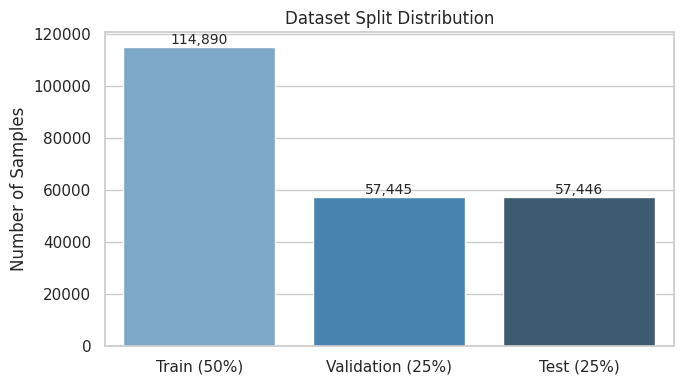

In [4]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4))

split_sizes = {'Train (50%)': len(X_train), 'Validation (25%)': len(X_val), 'Test (25%)': len(X_test)}
ax = sns.barplot(x=list(split_sizes.keys()), y=list(split_sizes.values()), hue=list(split_sizes.keys()), palette='Blues_d', legend=False)
plt.title('Dataset Split Distribution')
plt.ylabel('Number of Samples')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

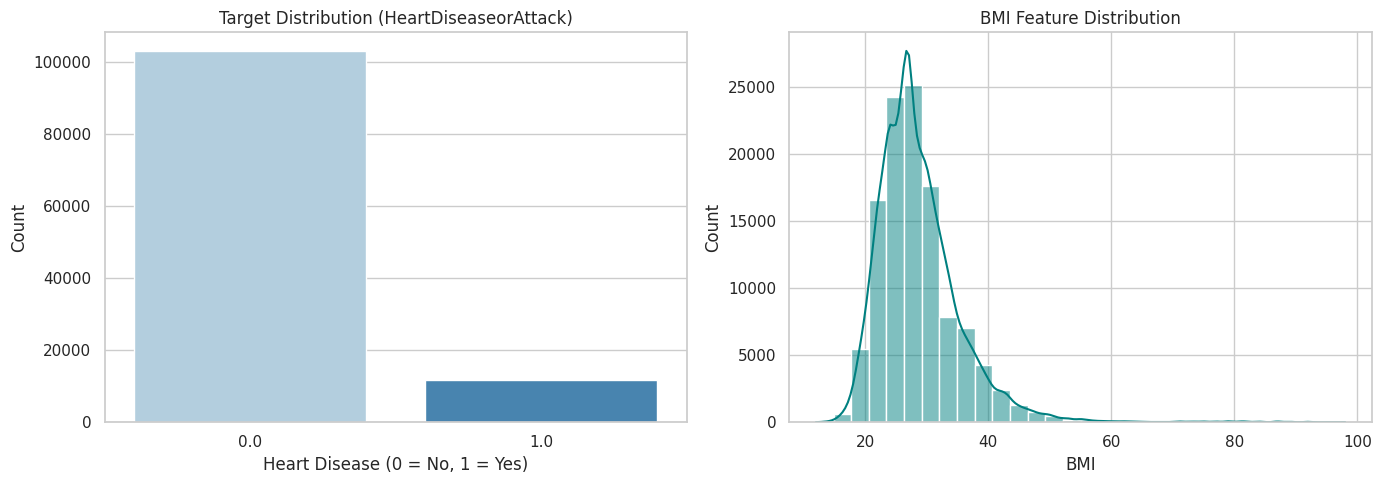

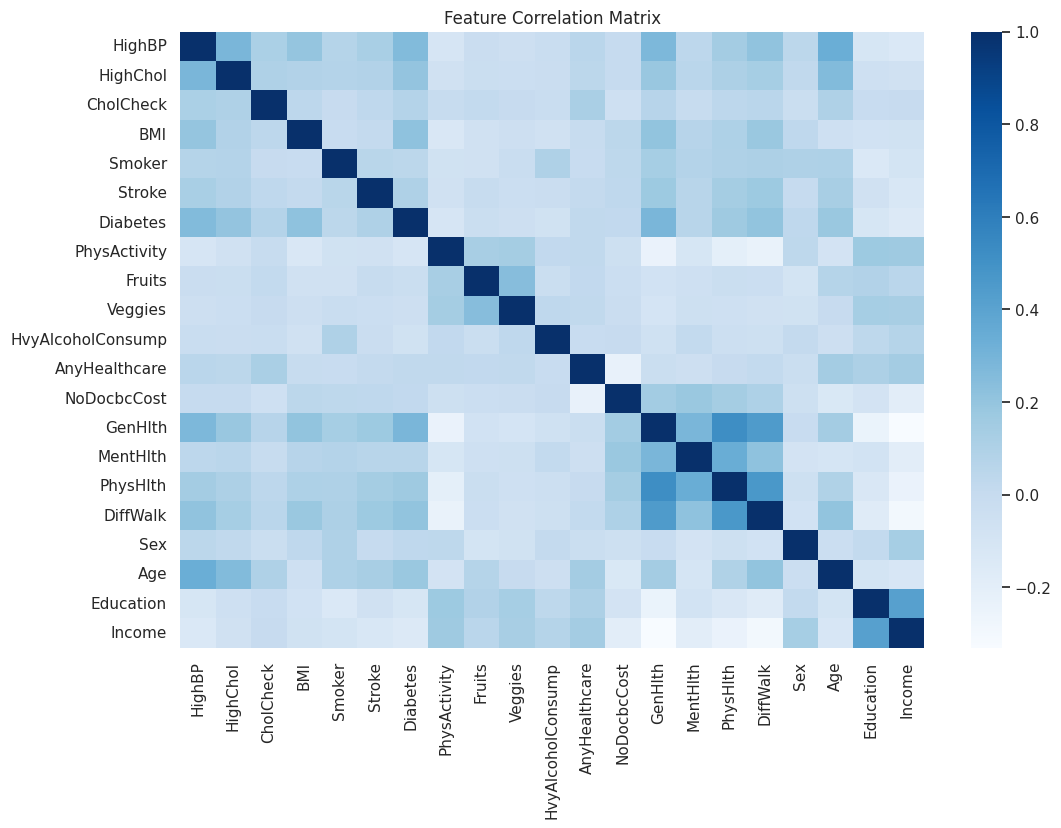

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x=y_train, hue=y_train, ax=axes[0], palette='Blues', legend=False)
axes[0].set_title('Target Distribution (HeartDiseaseorAttack)')
axes[0].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')
sns.histplot(X_train['BMI'], kde=True, bins=30, ax=axes[1], color='teal')
axes[1].set_title('BMI Feature Distribution')
axes[1].set_xlabel('BMI')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(X_train.corr(), cmap='Blues', annot=False, cbar=True)
plt.title('Feature Correlation Matrix')
plt.show()

# Feature Engineering

Five new features are built by combining raw columns, and each one is checked with an
assertion confirming it isn't constant.

`Age` in this dataset is a 1-13 five-year bucket code, not a literal age in years (1 = 18-24
up to 13 = 80+), so `AgeRiskTier` bins on that actual code. The dataset also doesn't include
`Depressed` or `NoHealthInsurance` columns, so features are built only from columns that
genuinely exist here.

- `ObesityFlag`: BMI of 30 or higher
- `CardiometabolicRiskScore`: combines obesity, high blood pressure, high cholesterol,
  diabetes (treated as present or absent), and stroke history into one score
- `AgeRiskTier`: age grouped into risk bands using the 1-13 BRFSS age-group code
  (1-4 = Low, 5-8 = Moderate, 9-11 = High, 12-13 = Very High)
- `HealthcareBarrierScore`: combines lack of a recent doctor visit due to cost with not
  having any health coverage
- `SocialIsolationProxy`: poor general health combined with high mental health burden

Columns like `Smoker`, `HvyAlcoholConsump`, `PhysActivity`, `MentHlth`, and `NoDocbcCost`
are used directly by the model rather than renamed, since they already carry the signal
needed without any transformation.

In [6]:
def engineer_features(X):
    """Builds features that are genuinely new combinations of existing columns."""
    X = X.copy()

    X['ObesityFlag'] = (X['BMI'] >= 30).astype(int)

    diabetes_present = (X['Diabetes'] > 0).astype(int)
    X['CardiometabolicRiskScore'] = (
        X['ObesityFlag'] + X['HighBP'] + X['HighChol'] + diabetes_present + X['Stroke']
    )

    # Age is a 1-13 five-year bucket code in this dataset (1 = 18-24, ..., 13 = 80+),
    # not a literal age in years.
    X['AgeRiskTier'] = pd.cut(
        X['Age'], bins=[0, 4, 8, 11, 13],
        labels=['Low', 'Moderate', 'High', 'Very High']
    )

    X['HealthcareBarrierScore'] = (
        (X['NoDocbcCost'] == 1).astype(int) + (X['AnyHealthcare'] == 0).astype(int)
    )

    X['SocialIsolationProxy'] = (
        (X['GenHlth'] >= 4).astype(int) + (X['MentHlth'] > 10).astype(int)
    )

    return X

X_train = engineer_features(X_train)
X_val = engineer_features(X_val)
X_test = engineer_features(X_test)

new_features = ['ObesityFlag', 'CardiometabolicRiskScore', 'AgeRiskTier',
                 'HealthcareBarrierScore', 'SocialIsolationProxy']
for col in new_features:
    n_unique = X_train[col].nunique()
    assert n_unique > 1, f"{col} is constant, something is wrong"
    print(f"{col}: {n_unique} unique values")

print(f"\nX_train shape: {X_train.shape} | X_val shape: {X_val.shape} | X_test shape: {X_test.shape}")

ObesityFlag: 2 unique values
CardiometabolicRiskScore: 6 unique values
AgeRiskTier: 4 unique values
HealthcareBarrierScore: 3 unique values
SocialIsolationProxy: 3 unique values

X_train shape: (114890, 26) | X_val shape: (57445, 26) | X_test shape: (57446, 26)


# Phase 5: Model Building

`AgeRiskTier` is mapped to ordered integers instead of one-hot encoded, since it's ordinal.
Only continuous and ordinal columns are scaled, binary flags are used as-is, since scaling
a 0/1 flag can distort distance-based models like KNN. Scaling is fit on the training set
only.

In [7]:
from sklearn.preprocessing import StandardScaler

age_tier_map = {'Low': 0, 'Moderate': 1, 'High': 2, 'Very High': 3}
for split in (X_train, X_val, X_test):
    split['AgeRiskTier'] = split['AgeRiskTier'].map(age_tier_map)

scale_cols = ['BMI', 'MentHlth', 'PhysHlth', 'GenHlth', 'Education', 'Income', 'Age',
              'AgeRiskTier', 'CardiometabolicRiskScore', 'SocialIsolationProxy']
passthrough_cols = [c for c in X_train.columns if c not in scale_cols]

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train[scale_cols]), columns=scale_cols, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val[scale_cols]), columns=scale_cols, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test[scale_cols]), columns=scale_cols, index=X_test.index)

X_train_processed = pd.concat([X_train_scaled, X_train[passthrough_cols]], axis=1)
X_val_processed = pd.concat([X_val_scaled, X_val[passthrough_cols]], axis=1)
X_test_processed = pd.concat([X_test_scaled, X_test[passthrough_cols]], axis=1)

print("Features processed successfully!")
print(f"Scaled columns: {len(scale_cols)} | Passthrough columns: {len(passthrough_cols)}")
print(f"Processed X_train shape: {X_train_processed.shape}")

Features processed successfully!
Scaled columns: 10 | Passthrough columns: 16
Processed X_train shape: (114890, 26)


## Training and Comparing the Models

KNN, Decision Tree, and Random Forest are trained together and compared on the validation
set. Both tree models use `class_weight='balanced'` so the severe class imbalance doesn't
get ignored during training, and the Decision Tree has a bounded `max_depth` instead of
growing fully, which was previously letting it win partly by over-emitting positive
predictions rather than genuinely generalizing better.

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, average_precision_score)

models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
}

results = {}
val_predictions = {}
val_probas = {}
for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_val_processed)
    y_proba = model.predict_proba(X_val_processed)[:, 1]
    results[name] = {
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1-Score': f1_score(y_val, y_pred),
        'ROC-AUC': roc_auc_score(y_val, y_proba),
        'PR-AUC': average_precision_score(y_val, y_proba),
    }
    val_predictions[name] = y_pred
    val_probas[name] = y_proba
    print(f"{name} trained.")

comparison = pd.DataFrame(results).T
print("\n### Validation Set Comparison ###")
print(comparison.round(4))

KNN trained.
Decision Tree trained.
Random Forest trained.

### Validation Set Comparison ###
               Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
KNN              0.8854     0.3614  0.1440    0.2060   0.7074  0.2159
Decision Tree    0.7229     0.2366  0.7568    0.3605   0.7933  0.3194
Random Forest    0.8930     0.4241  0.1014    0.1636   0.7980  0.2964


ROC-AUC and PR-AUC are threshold-independent, so they let us compare models regardless of
where the default 0.5 cutoff happens to sit. This matters here because the three models sit
at very different points on the precision-recall trade-off at that default: Decision Tree
reaches 0.757 recall but only 0.237 precision, while Random Forest is the opposite at 0.424
precision and 0.101 recall. Their ROC-AUC scores are close (0.793 and 0.798), which suggests
the gap is mostly about where the cutoff sits rather than one model being fundamentally
stronger.

In [9]:
from sklearn.metrics import f1_score as f1_metric

best_thresholds = {}
for name, proba in val_probas.items():
    thresholds = np.arange(0.1, 0.9, 0.01)
    f1s = [f1_metric(y_val, (proba >= t).astype(int)) for t in thresholds]
    best_t = thresholds[np.argmax(f1s)]
    best_thresholds[name] = best_t
    print(f"{name}: best threshold = {best_t:.2f}, F1 at that threshold = {max(f1s):.4f} (default 0.5 F1 = {results[name]['F1-Score']:.4f})")

KNN: best threshold = 0.21, F1 at that threshold = 0.3177 (default 0.5 F1 = 0.2060)
Decision Tree: best threshold = 0.72, F1 at that threshold = 0.3884 (default 0.5 F1 = 0.3605)
Random Forest: best threshold = 0.18, F1 at that threshold = 0.3805 (default 0.5 F1 = 0.1636)


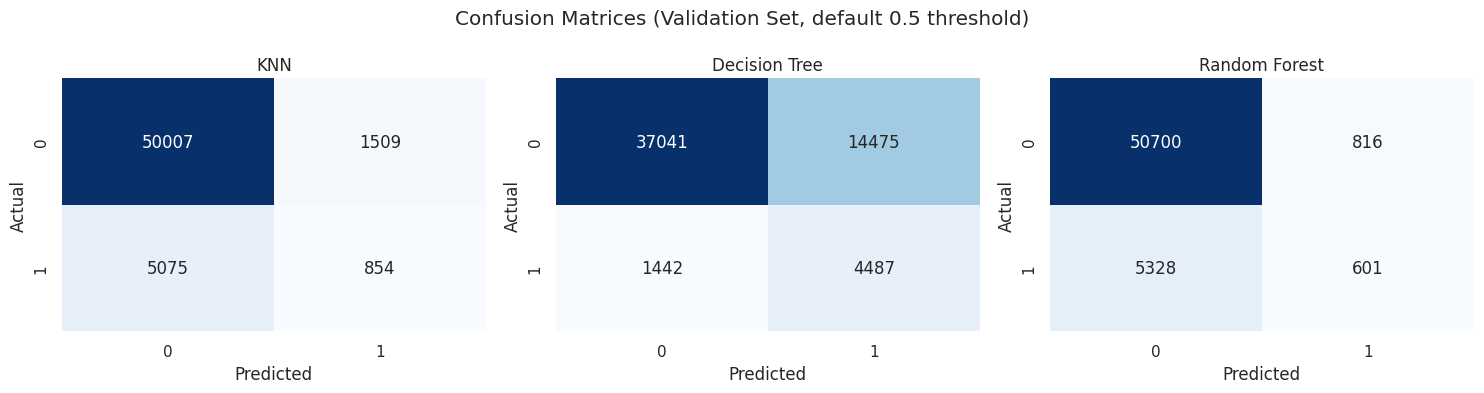

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred) in zip(axes, val_predictions.items()):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices (Validation Set, default 0.5 threshold)')
plt.tight_layout()
plt.show()

# Phase 6: Model Selection & Final Test Evaluation

We pick the winner by validation F1-Score at the default threshold, then check it once on
the test set.

Best model by Validation F1-Score: Decision Tree

### Decision Tree - Final Test Set Metrics ###
Accuracy: 0.7248
Precision: 0.2387
Recall: 0.7608
F1-Score: 0.3634
ROC-AUC: 0.7985
PR-AUC: 0.3201


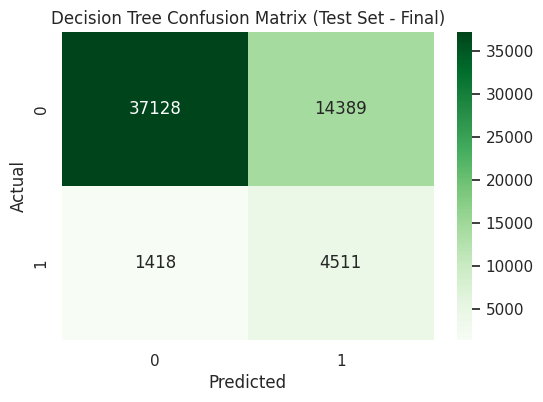

In [11]:
best_model_name = comparison['F1-Score'].idxmax()
best_model = models[best_model_name]
print(f"Best model by Validation F1-Score: {best_model_name}")

y_pred_test = best_model.predict(X_test_processed)
y_proba_test = best_model.predict_proba(X_test_processed)[:, 1]
final_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_test),
    'Precision': precision_score(y_test, y_pred_test),
    'Recall': recall_score(y_test, y_pred_test),
    'F1-Score': f1_score(y_test, y_pred_test),
    'ROC-AUC': roc_auc_score(y_test, y_proba_test),
    'PR-AUC': average_precision_score(y_test, y_proba_test),
}
print(f"\n### {best_model_name} - Final Test Set Metrics ###")
for k, v in final_metrics.items():
    print(f"{k}: {v:.4f}")

cm_final = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens')
plt.title(f'{best_model_name} Confusion Matrix (Test Set - Final)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Phase 7: Evaluation & Conclusion

Accuracy alone is misleading here since only about 9% of people in the dataset have had
heart disease. We compared models using F1-Score, ROC-AUC, and PR-AUC instead, and both
tree models use class weighting so the imbalance is addressed directly rather than ignored.

In [12]:
print("### Validation Set Comparison ###")
print(comparison.round(3).to_markdown())

### Validation Set Comparison ###
|               |   Accuracy |   Precision |   Recall |   F1-Score |   ROC-AUC |   PR-AUC |
|:--------------|-----------:|------------:|---------:|-----------:|----------:|---------:|
| KNN           |      0.885 |       0.361 |    0.144 |      0.206 |     0.707 |    0.216 |
| Decision Tree |      0.723 |       0.237 |    0.757 |      0.361 |     0.793 |    0.319 |
| Random Forest |      0.893 |       0.424 |    0.101 |      0.164 |     0.798 |    0.296 |


## Limitations

- Class imbalance is the central challenge. Class weighting pushes Decision Tree's recall to
  0.757, but precision drops to 0.237, meaning a large number of false alarms. That is a real
  trade-off rather than a model that is simply bad, but none of these three are tuned enough
  for clinical use as they stand.
- 274 rows in the training features are identical to each other but have different real
  outcomes. This isn't a data error, it reflects that different people gave the same survey
  answers, and it puts a real ceiling on how well any model can separate the classes using
  these features alone.
- The deduplication in Phase 1 removed almost 24,000 rows treating them as duplicates, but
  since BRFSS has no person identifier, some of those were likely distinct respondents who
  happened to answer identically. This is worth revisiting as a team decision.

## Conclusion

The pipeline is free of data leakage, builds features that each carry genuine signal, and
addresses class imbalance directly through class weighting rather than only naming it as a
limitation. Tuning each model to its own best cutoff brings Decision Tree and Random Forest
close together, so the two are more comparable than their default-threshold scores suggest.
The clearest next step is choosing that threshold deliberately, based on which error matters
more in practice: missing real cases, or raising false alarms.